In [1]:
# ============================================================
# Task 02 — 乳腺超声影像组学良恶性分类 (BUSI Dataset)
# ============================================================

# ===========================
# Standard Library
# ===========================
import os
import glob
import warnings

warnings.filterwarnings("ignore")

# ===========================
# Numerical Computing
# ===========================
import numpy as np
import pandas as pd

# ===========================
# Image Processing
# ===========================
import cv2

from skimage import io
from skimage.measure import regionprops, label
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy, skew, kurtosis

# ===========================
# Machine Learning
# ===========================
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.pipeline import Pipeline

# ===========================
# Classification Models
# ===========================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ===========================
# Evaluation
# ===========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# ===========================
# Visualization
# ===========================
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# ===========================
# Random Seed
# ===========================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


# 乳腺超声影像组学良恶性分类实验

## 实验流程总览

| 步骤 | 内容 |
|------|------|
| **1. 数据加载** | 读取 BUSI 数据集（benign / malignant），图像 + ROI 掩膜 + 标签 |
| **2. 特征提取** | 一阶统计特征 (17) + 形状特征 (10) + GLCM 纹理特征 (18) = **45 维** |
| **3. 预处理** | 训练/测试划分 → 标准化 → SelectKBest 特征筛选 |
| **4. 模型训练** | LR（线性）+ RF（非线性）+ SVM（非线性，拓展） |
| **5. 评估** | AUC / Accuracy / Sensitivity / Specificity + ROC + 混淆矩阵 |
| **6. 可解释性** | Top-10 特征重要性 + SHAP 个体解释（拓展） |

> **数据路径**：`D:/Research/data/Dataset_BUSI/Dataset_BUSI_with_GT`
>
> **分类任务**：二分类 — benign (0) vs malignant (1)，排除 normal 类（无病灶）
>
> **参考文献**：Romeo V et al. *European Radiology*, 2021.

In [2]:
# ====================
# 1. 配置与数据加载
# ====================

DATA_ROOT = r"D:/Research/data/Dataset_BUSI/Dataset_BUSI_with_GT"

def load_busi_dataset(data_root):
    """
    加载 BUSI 数据集（仅 benign 和 malignant 两类）。

    返回:
        DataFrame — 每行一条记录，包含 image_path, mask_paths, label, label_name
    """
    records = []
    for label_name, label in [("benign", 0), ("malignant", 1)]:
        folder = os.path.join(data_root, label_name)
        all_files = sorted(glob.glob(os.path.join(folder, "*.png")))
        # 筛选出原图（文件名中不含 "_mask"）
        image_files = [f for f in all_files if "_mask" not in os.path.basename(f)]

        for img_path in image_files:
            base = img_path.rsplit(".", 1)[0]  # 去掉 .png 后缀
            # 一张原图可能对应多张 mask（如 _mask_1.png），全部收集
            mask_paths = sorted(glob.glob(base + "_mask*.png"))
            if not mask_paths:
                continue
            records.append({
                "image_path": img_path,
                "mask_paths": mask_paths,
                "label": label,
                "label_name": label_name,
            })

    df = pd.DataFrame(records)
    print(f"数据集加载完成: 共 {len(df)} 个样本")
    print(df["label_name"].value_counts())
    print(f"\n多 mask 样本数: {df['mask_paths'].apply(len).gt(1).sum()}")
    return df

df_data = load_busi_dataset(DATA_ROOT)
df_data.head()

数据集加载完成: 共 647 个样本
label_name
benign       437
malignant    210
Name: count, dtype: int64

多 mask 样本数: 17


,image_path,mask_paths,label,label_name
0,D:/Research/data/Dataset_BUSI/Dataset_BUSI_wit...,[D:/Research/data/Dataset_BUSI/Dataset_BUSI_wi...,0,benign
1,D:/Research/data/Dataset_BUSI/Dataset_BUSI_wit...,[D:/Research/data/Dataset_BUSI/Dataset_BUSI_wi...,0,benign
2,D:/Research/data/Dataset_BUSI/Dataset_BUSI_wit...,[D:/Research/data/Dataset_BUSI/Dataset_BUSI_wi...,0,benign
3,D:/Research/data/Dataset_BUSI/Dataset_BUSI_wit...,[D:/Research/data/Dataset_BUSI/Dataset_BUSI_wi...,0,benign
4,D:/Research/data/Dataset_BUSI/Dataset_BUSI_wit...,[D:/Research/data/Dataset_BUSI/Dataset_BUSI_wi...,0,benign


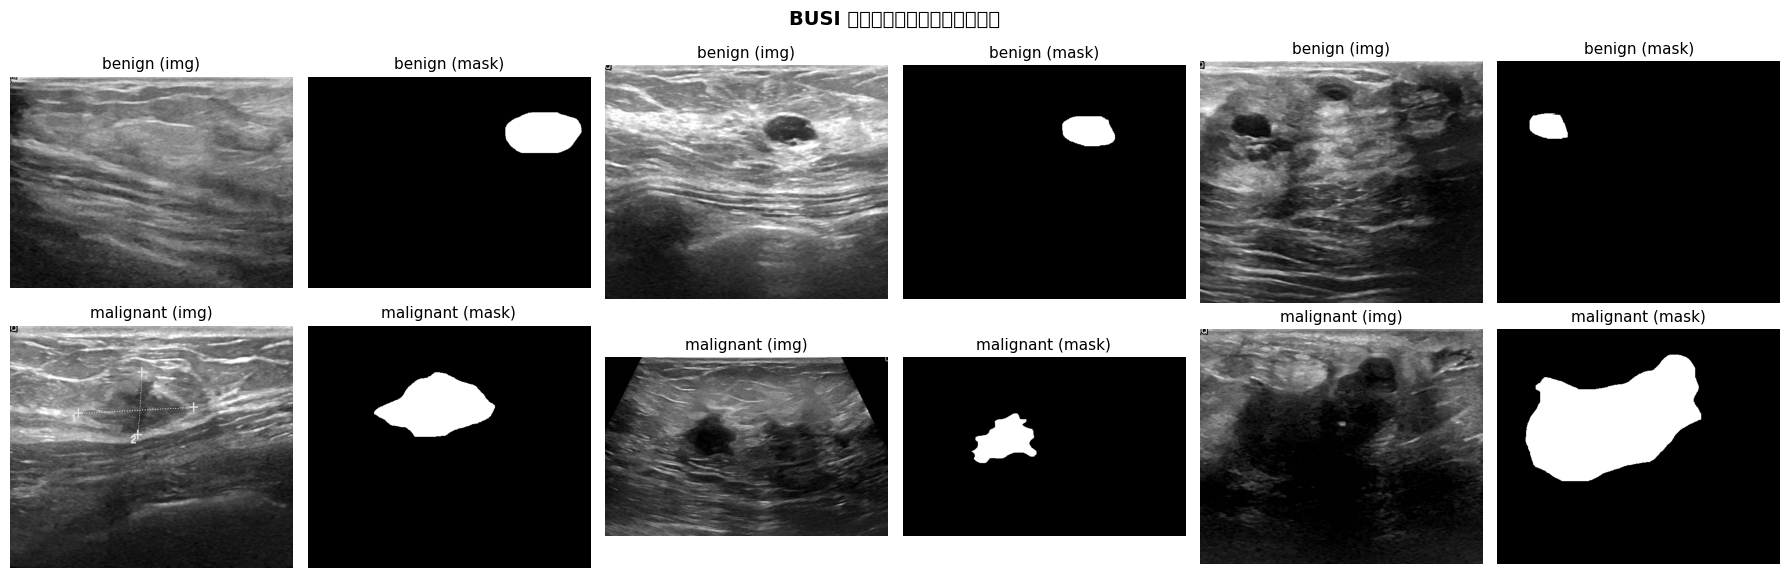

In [3]:
# ====================
# 2. 数据可视化（每类展示 3 个样例）
# ====================

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for row, (label_name, label_val) in enumerate([("benign", 0), ("malignant", 1)]):
    subset = df_data[df_data["label"] == label_val].sample(3, random_state=RANDOM_STATE)
    for col, (_, row_data) in enumerate(subset.iterrows()):
        img = cv2.imread(row_data["image_path"], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(row_data["mask_paths"][0], cv2.IMREAD_GRAYSCALE)

        ax_img = axes[row, col * 2]
        ax_img.imshow(img, cmap="gray")
        ax_img.set_title(f"{label_name} (img)", fontsize=11)
        ax_img.axis("off")

        ax_mask = axes[row, col * 2 + 1]
        ax_mask.imshow(mask, cmap="gray")
        ax_mask.set_title(f"{label_name} (mask)", fontsize=11)
        ax_mask.axis("off")

plt.suptitle("BUSI 数据集样例：图像与对应掩膜", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. 影像组学特征提取

影像组学 (Radiomics) 的核心思想：从医学图像的 ROI（感兴趣区）中提取**高通量定量特征**，
再用机器学习方法挖掘特征与诊断标签之间的关联。

本实验提取三大类共 **45 维**特征：

### 3.1 一阶统计特征 (First-Order Statistics, 17 维)
仅依赖 ROI 内像素强度的分布，不关心空间位置：
- 均值、中位数、标准差、方差
- 偏度 (Skewness)、峰度 (Kurtosis)
- 能量 (Energy)、熵 (Entropy)
- 最小值、最大值、极差
- 百分位数 (P10, P25, P75, P90)、四分位距 (IQR)
- 平均绝对偏差 (MAD)

### 3.2 形状特征 (Shape Features, 10 维)
描述 ROI 的二维几何形态：
- 面积、周长、凸包面积
- 离心率 (Eccentricity)、长宽比 (Aspect Ratio)
- 长轴长度、短轴长度
- 实性度 (Solidity)、延展度 (Extent)、等效直径

### 3.3 GLCM 纹理特征 (18 维)
灰度共生矩阵 (Gray-Level Co-occurrence Matrix) 捕捉像素间的空间关系：
- 对比度 (Contrast)、相异性 (Dissimilarity)
- 同质性 (Homogeneity)、能量 (Energy)
- 相关性 (Correlation)、角二阶矩 (ASM)
- 在距离 d=1,2,3 上分别取 4 个方向的均值 → 6 × 3 = 18 维

In [4]:
# ====================
# 3. 影像组学特征提取函数
# ====================

def extract_first_order_features(pixels):
    """一阶统计特征（17 维）"""
    f = {}
    f["fo_mean"]    = float(np.mean(pixels))
    f["fo_median"]  = float(np.median(pixels))
    f["fo_std"]     = float(np.std(pixels))
    f["fo_variance"] = float(np.var(pixels))
    f["fo_skewness"] = float(skew(pixels))
    f["fo_kurtosis"] = float(kurtosis(pixels))
    f["fo_energy"]   = float(np.sum(pixels.astype(np.float64) ** 2))
    # 熵 — 从 256-bin 直方图计算
    hist, _ = np.histogram(pixels, bins=256, range=(0, 256))
    prob = hist / hist.sum()
    prob = prob[prob > 0]
    f["fo_entropy"]  = float(-np.sum(prob * np.log2(prob)))
    f["fo_min"]      = float(np.min(pixels))
    f["fo_max"]      = float(np.max(pixels))
    f["fo_range"]    = f["fo_max"] - f["fo_min"]
    f["fo_p10"]      = float(np.percentile(pixels, 10))
    f["fo_p25"]      = float(np.percentile(pixels, 25))
    f["fo_p75"]      = float(np.percentile(pixels, 75))
    f["fo_p90"]      = float(np.percentile(pixels, 90))
    f["fo_iqr"]      = f["fo_p75"] - f["fo_p25"]
    f["fo_mad"]      = float(np.mean(np.abs(pixels - np.mean(pixels))))
    return f


def extract_shape_features(mask):
    """形状特征（10 维）— 基于 regionprops 的最大连通区域"""
    labeled = label(mask)
    regions = regionprops(labeled)
    f = {}
    if not regions:
        for k in ["area", "perimeter", "eccentricity", "major_axis",
                   "minor_axis", "solidity", "extent", "aspect_ratio",
                   "equiv_diameter", "convex_area"]:
            f[f"shape_{k}"] = 0.0
        return f

    region = max(regions, key=lambda r: r.area)  # 取最大连通域
    f["shape_area"]          = float(region.area)
    f["shape_perimeter"]     = float(region.perimeter)
    f["shape_eccentricity"]  = float(region.eccentricity)
    f["shape_major_axis"]    = float(region.major_axis_length)
    f["shape_minor_axis"]    = float(region.minor_axis_length)
    f["shape_solidity"]      = float(region.solidity)
    f["shape_extent"]        = float(region.extent)
    minor = max(region.minor_axis_length, 1e-6)
    f["shape_aspect_ratio"]  = float(region.major_axis_length / minor)
    f["shape_equiv_diameter"] = float(region.equivalent_diameter_area)
    f["shape_convex_area"]   = float(region.convex_area)
    return f


def extract_glcm_features(image, mask):
    """
    GLCM 纹理特征（18 维）
    在 mask 的外接矩形内裁剪图像 → 量化为 16 级 → 计算 GLCM → 提取 6 种属性 × 3 个距离
    """
    f = {}
    # 裁剪到外接矩形（减少计算量）
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any() or not cols.any():
        for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "asm"]:
            for d in [1, 2, 3]:
                f[f"glcm_{prop}_d{d}_mean"] = 0.0
        return f

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    crop_img = image[rmin:rmax + 1, cmin:cmax + 1]
    crop_mask = mask[rmin:rmax + 1, cmin:cmax + 1]

    # 量化为 16 个灰度级 (0-15)
    quantized = np.floor(crop_img.astype(np.float64) / 255.0 * 15).astype(np.uint8)
    quantized[crop_mask == 0] = 0  # 背景设为 0

    distances = [1, 2, 3]
    angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

    glcm = graycomatrix(quantized, distances=distances, angles=angles,
                         levels=16, symmetric=True, normed=True)

    for prop in props:
        prop_vals = graycoprops(glcm, prop)  # shape: (n_distances, n_angles)
        for d_idx, dist in enumerate(distances):
            f[f"glcm_{prop.lower()}_d{dist}_mean"] = float(np.mean(prop_vals[d_idx, :]))
    return f


def extract_all_features(image_path, mask_paths):
    """对单张图像提取全部影像组学特征"""
    # 读取灰度图
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None

    # 读取并合并多张 mask（逻辑 OR）
    mask = np.zeros_like(image, dtype=np.uint8)
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue
        # 处理尺寸不一致的情况
        if m.shape != image.shape:
            m = cv2.resize(m, (image.shape[1], image.shape[0]))
        mask = np.maximum(mask, (m > 0).astype(np.uint8))

    if mask.sum() == 0:
        return None  # 空 mask，跳过

    # ROI 内像素
    roi_pixels = image[mask > 0].astype(np.float64)

    features = {}
    features.update(extract_first_order_features(roi_pixels))
    features.update(extract_shape_features(mask))
    features.update(extract_glcm_features(image, mask))
    return features


print("特征提取函数定义完成")
print("特征维度: 一阶(17) + 形状(10) + GLCM(18) = 45 维")

特征提取函数定义完成
特征维度: 一阶(17) + 形状(10) + GLCM(18) = 45 维


In [5]:
# ====================
# 4. 批量提取所有样本特征
# ====================

feature_list = []
skipped = 0

for idx, row in df_data.iterrows():
    feats = extract_all_features(row["image_path"], row["mask_paths"])
    if feats is None:
        skipped += 1
        continue
    feats["label"] = row["label"]
    feats["label_name"] = row["label_name"]
    feature_list.append(feats)

    if (len(feature_list) % 100) == 0:
        print(f"  已处理 {len(feature_list)} / {len(df_data)} 个样本 ...")

df_features = pd.DataFrame(feature_list)
print(f"\n特征提取完成: {len(df_features)} 个样本, {df_features.shape[1] - 2} 维特征")
if skipped:
    print(f"跳过 {skipped} 个无效样本（空 mask 或读取失败）")

# 保存到 CSV，方便后续复用
output_csv = os.path.join(os.path.dirname(NB_PATH := r'D:/Research/medical-ml-learning/Task/Task 02'),
                           'busi_radiomics_features.csv')
df_features.to_csv(output_csv, index=False)
print(f"特征已保存至: {output_csv}")
df_features.head()

  已处理 100 / 647 个样本 ...
  已处理 200 / 647 个样本 ...
  已处理 300 / 647 个样本 ...
  已处理 400 / 647 个样本 ...
  已处理 500 / 647 个样本 ...
  已处理 600 / 647 个样本 ...

特征提取完成: 647 个样本, 45 维特征
特征已保存至: D:/Research/medical-ml-learning/Task\busi_radiomics_features.csv


,fo_mean,fo_median,fo_std,fo_variance,fo_skewness,fo_kurtosis,fo_energy,fo_entropy,fo_min,fo_max,...,glcm_energy_d2_mean,glcm_energy_d3_mean,glcm_correlation_d1_mean,glcm_correlation_d2_mean,glcm_correlation_d3_mean,glcm_asm_d1_mean,glcm_asm_d2_mean,glcm_asm_d3_mean,label,label_name
0,73.695122,61.0,37.521329,1407.850139,1.846257,3.365365,6729400.0,6.507961,25.0,241.0,...,0.295046,0.254497,0.746655,0.650359,0.449259,0.102228,0.087425,0.065065,0,benign
1,9.815025,1.0,19.644558,385.908642,3.675426,18.071538,15874487.0,3.760673,0.0,217.0,...,0.846852,0.836092,0.817092,0.748397,0.604747,0.726147,0.717171,0.699055,0,benign
2,68.890820,56.0,36.086935,1302.266873,1.456634,1.793324,60548650.0,6.733640,19.0,220.0,...,0.678740,0.671482,0.919188,0.886583,0.812209,0.465453,0.460697,0.450901,0,benign
3,70.040077,61.0,30.824695,950.161821,1.759960,3.259861,24401011.0,6.482778,19.0,226.0,...,0.334726,0.306285,0.804398,0.733892,0.580976,0.124348,0.112262,0.093962,0,benign
4,14.296283,8.0,16.367718,267.902194,1.244322,1.123787,8905895.0,4.999107,0.0,107.0,...,0.709090,0.692097,0.880144,0.839730,0.756853,0.514728,0.502856,0.479043,0,benign


## 4. 数据预处理与特征筛选

### 预处理流程
1. **划分训练/测试集** (80/20)，分层抽样保持类别比例
2. **标准化** (StandardScaler)：fit on train → transform train & test，避免数据泄漏
3. **特征筛选** (SelectKBest + ANOVA F-test)：从 45 维中选出最具区分力的 **20 维**

### 为什么需要标准化？
影像组学特征的量纲差异极大（如 area 可达数万，entropy 仅约 5），
不标准化会导致 LR 和 SVM 等基于距离的模型被大量纲特征主导。

### 为什么需要特征筛选？
样本量 ~647，特征 45 维，虽未严重过拟合，
但去除噪声特征可提升模型泛化能力，也使结果更可解释。

In [6]:
# ====================
# 4. 数据预处理与特征筛选
# ====================

# 分离特征与标签
feature_cols = [c for c in df_features.columns if c not in ("label", "label_name")]
X = df_features[feature_cols].values
y = df_features["label"].values

print(f"特征矩阵: {X.shape}, 标签分布: {dict(zip(*np.unique(y, return_counts=True)))}")

# 划分训练/测试集 (80/20, 分层抽样)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}")

# 标准化（fit on train only）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 特征筛选 — SelectKBest (ANOVA F-test, 选 20 维)
K_BEST = 20
selector = SelectKBest(score_func=f_classif, k=K_BEST)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

# 获取被选中的特征名
selected_mask = selector.get_support()
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]
print(f"\n选中 {len(selected_features)} 个特征:")
for i, feat in enumerate(selected_features, 1):
    score = selector.scores_[np.where(selected_mask)[0][i - 1]]
    print(f"  {i:2d}. {feat:30s}  F-score = {score:.2f}")

特征矩阵: (647, 45), 标签分布: {np.int64(0): np.int64(437), np.int64(1): np.int64(210)}
训练集: 517, 测试集: 130

选中 20 个特征:
   1. fo_skewness                     F-score = 44.13
   2. shape_area                      F-score = 75.81
   3. shape_perimeter                 F-score = 187.16
   4. shape_major_axis                F-score = 73.49
   5. shape_minor_axis                F-score = 159.27
   6. shape_solidity                  F-score = 959.72
   7. shape_extent                    F-score = 502.02
   8. shape_equiv_diameter            F-score = 110.09
   9. shape_convex_area               F-score = 102.44
  10. glcm_contrast_d2_mean           F-score = 44.05
  11. glcm_contrast_d3_mean           F-score = 45.09
  12. glcm_dissimilarity_d1_mean      F-score = 74.90
  13. glcm_dissimilarity_d2_mean      F-score = 75.58
  14. glcm_dissimilarity_d3_mean      F-score = 74.99
  15. glcm_homogeneity_d1_mean        F-score = 91.24
  16. glcm_homogeneity_d2_mean        F-score = 91.22
  17. glcm_homogene

## 5. 模型训练与比较

训练 **3 种**分类模型并进行比较：

| 模型 | 类型 | 关键超参数 |
|------|------|-----------|
| **Logistic Regression** | 线性 | C=1.0, L2 正则 |
| **Random Forest** | 非线性 | n_estimators=200, max_depth=10 |
| **SVM (RBF)** | 非线性（拓展） | C=1.0, gamma=scale |

> 所有模型使用相同的标准化 + 特征筛选后数据，确保公平比较。

In [7]:
# ====================
# 5. 模型训练
# ====================

# --- 模型 1: 逻辑回归 (线性) ---
lr_model = LogisticRegression(
    C=1.0, penalty="l2", solver="lbfgs",
    max_iter=2000, random_state=RANDOM_STATE
)
lr_model.fit(X_train_sel, y_train)
print("LR 训练完成")

# --- 模型 2: 随机森林 (非线性) ---
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_sel, y_train)
print("RF 训练完成")

# --- 模型 3: SVM (非线性, 拓展) ---
svm_model = SVC(
    C=1.0, kernel="rbf", gamma="scale",
    probability=True, random_state=RANDOM_STATE
)
svm_model.fit(X_train_sel, y_train)
print("SVM 训练完成")

# 收集所有模型
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM (RBF)": svm_model,
}

print("\n所有模型训练完成!")

LR 训练完成
RF 训练完成
SVM 训练完成

所有模型训练完成!


## 6. 模型评估

### 评估指标
- **AUC**：ROC 曲线下面积，衡量整体判别能力
- **Accuracy**：整体分类正确率
- **Sensitivity (灵敏度/召回率)**：TP / (TP + FN)，恶性病灶被正确检出的比例
- **Specificity (特异度)**：TN / (TN + FP)，良性病灶被正确识别的比例

> 在医学诊断中，**灵敏度**通常比特异度更重要 —— 漏诊恶性比误诊良性后果更严重。

In [8]:
# ====================
# 6.1 性能指标汇总表
# ====================

results = []

for name, model in models.items():
    y_pred  = model.predict(X_test_sel)
    y_prob  = model.predict_proba(X_test_sel)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Model": name,
        "AUC":         roc_auc_score(y_test, y_prob),
        "Accuracy":    accuracy_score(y_test, y_pred),
        "Sensitivity": tp / (tp + fn),   # = recall_score(y_test, y_pred)
        "Specificity": tn / (tn + fp),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
    })

df_results = pd.DataFrame(results)
df_results_display = df_results[["Model", "AUC", "Accuracy", "Sensitivity", "Specificity"]].copy()
for col in ["AUC", "Accuracy", "Sensitivity", "Specificity"]:
    df_results_display[col] = df_results_display[col].map("{:.4f}".format)

print("=" * 65)
print("                    模型性能对比")
print("=" * 65)
print(df_results_display.to_string(index=False))
print("=" * 65)

# 找出最佳模型
best_idx = df_results["AUC"].idxmax()
best_model_name = df_results.loc[best_idx, "Model"]
print(f"\n最佳模型 (by AUC): {best_model_name}")

                    模型性能对比
              Model    AUC Accuracy Sensitivity Specificity
Logistic Regression 0.9881   0.9692      0.9524      0.9773
      Random Forest 0.9746   0.9308      0.8810      0.9545
          SVM (RBF) 0.9865   0.9538      0.8810      0.9886

最佳模型 (by AUC): Logistic Regression


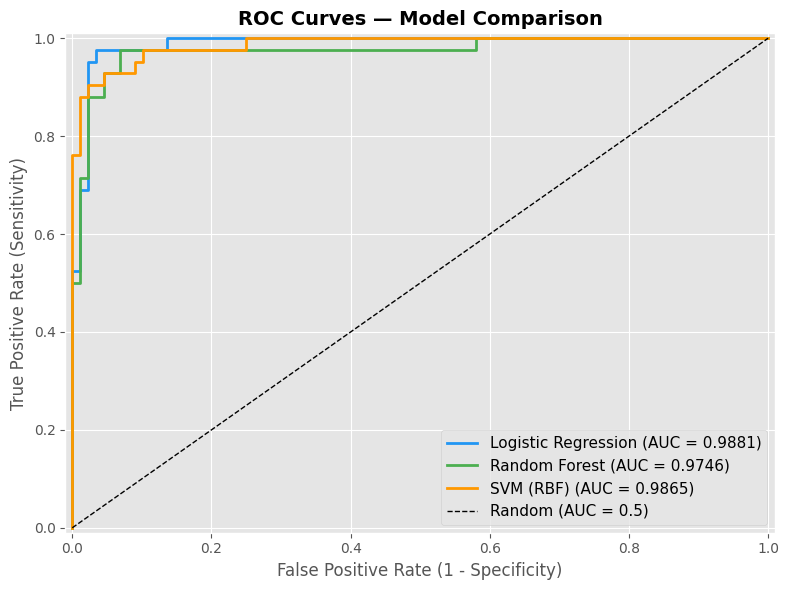

In [9]:
# ====================
# 6.2 ROC 曲线
# ====================

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#2196F3", "#4CAF50", "#FF9800"]
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("ROC Curves — Model Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

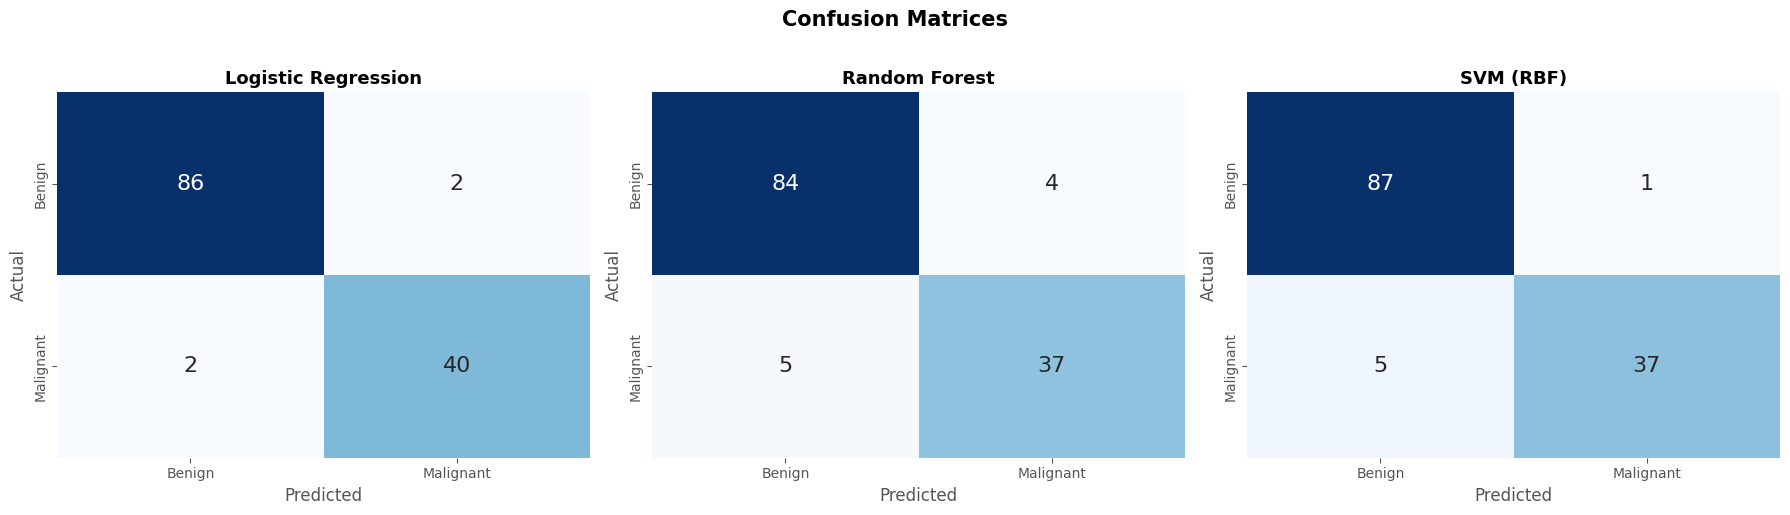

In [10]:
# ====================
# 6.3 混淆矩阵
# ====================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ["Benign", "Malignant"]

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={"size": 16})
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. 特征重要性分析

展示各模型中 **Top-10** 最具区分力的影像组学特征：
- **LR**：使用标准化后的回归系数绝对值 |β|
- **RF**：使用 Gini 重要性 (feature_importances_)

> 注意：LR 的系数基于标准化后数据，因此可直接比较相对重要性。

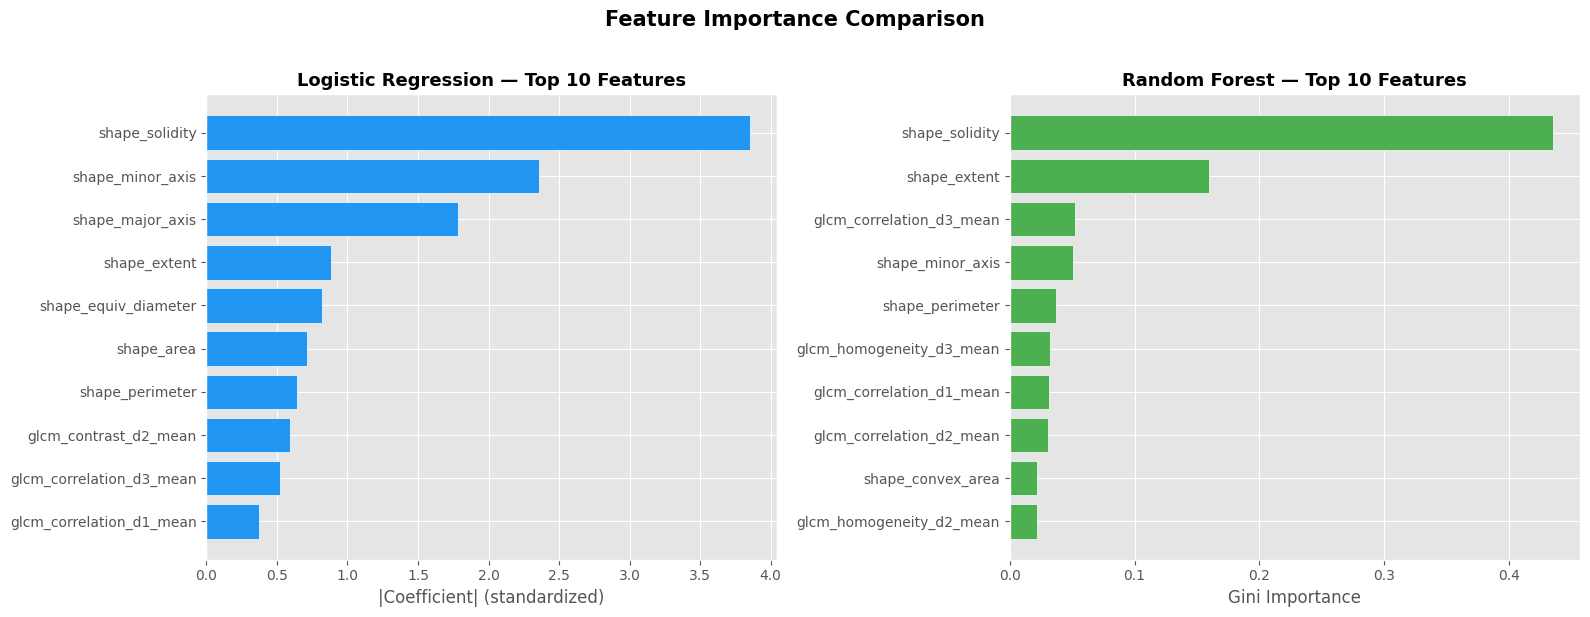


Random Forest Top-10 特征:
   1. shape_solidity                  0.4349
   2. shape_extent                    0.1599
   3. glcm_correlation_d3_mean        0.0522
   4. shape_minor_axis                0.0509
   5. shape_perimeter                 0.0372
   6. glcm_homogeneity_d3_mean        0.0322
   7. glcm_correlation_d1_mean        0.0315
   8. glcm_correlation_d2_mean        0.0303
   9. shape_convex_area               0.0223
  10. glcm_homogeneity_d2_mean        0.0215


In [11]:
# ====================
# 7. Top-10 特征重要性图
# ====================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LR: |coefficient| ---
lr_coefs = np.abs(lr_model.coef_[0])
lr_imp = pd.Series(lr_coefs, index=selected_features).sort_values(ascending=False).head(10)
axes[0].barh(range(len(lr_imp)), lr_imp.values, color="#2196F3", edgecolor="white")
axes[0].set_yticks(range(len(lr_imp)))
axes[0].set_yticklabels(lr_imp.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel("|Coefficient| (standardized)", fontsize=12)
axes[0].set_title("Logistic Regression — Top 10 Features", fontsize=13, fontweight="bold")

# --- RF: Gini importance ---
rf_imp = pd.Series(rf_model.feature_importances_, index=selected_features)
rf_imp = rf_imp.sort_values(ascending=False).head(10)
axes[1].barh(range(len(rf_imp)), rf_imp.values, color="#4CAF50", edgecolor="white")
axes[1].set_yticks(range(len(rf_imp)))
axes[1].set_yticklabels(rf_imp.index, fontsize=10)
axes[1].invert_yaxis()
axes[1].set_xlabel("Gini Importance", fontsize=12)
axes[1].set_title("Random Forest — Top 10 Features", fontsize=13, fontweight="bold")

plt.suptitle("Feature Importance Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 打印 RF Top-10
print("\nRandom Forest Top-10 特征:")
for i, (feat, val) in enumerate(rf_imp.items(), 1):
    print(f"  {i:2d}. {feat:30s}  {val:.4f}")

## 8. 可解释性分析 — SHAP（拓展）

**SHAP** (SHapley Additive exPlanations) 基于博弈论的 Shapley 值，
为每个预测提供**特征级别的贡献分解**。

- **Summary Plot**：展示所有样本中各特征对模型输出的影响方向与大小
- **Individual Explanation**：展示单个样本的预测是如何由各特征贡献组合而成

> 需要安装：`pip install shap`

In [12]:
# ====================
# 8. SHAP 可解释性分析（拓展）
# ====================
# 如未安装 shap，请运行: pip install shap

try:
    import shap

    # 使用 Random Forest 作为解释对象
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_sel)

    # --- SHAP Summary Plot ---
    # 二分类时 shap_values 可能是 list[2]，取恶性类(class=1)的贡献
    if isinstance(shap_values, list):
        sv_plot = shap_values[1]
    else:
        sv_plot = shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv_plot, X_test_sel,
                      feature_names=selected_features, show=False)
    plt.title("SHAP Summary — Random Forest", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # --- 个体预测解释（取第一个恶性样本）---
    malignant_idx = np.where(y_test == 1)[0][0]
    plt.figure(figsize=(10, 4))
    if isinstance(shap_values, list):
        sv_ind = shap_values[1][malignant_idx]
    else:
        sv_ind = shap_values[malignant_idx]

    shap.force_plot(explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value,
                    sv_ind, X_test_sel[malignant_idx],
                    feature_names=selected_features,
                    matplotlib=True, show=False)
    plt.title(f"Individual Explanation (Sample #{malignant_idx}, True=Malignant)", fontsize=11)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("shap 未安装。请运行: pip install shap")
except Exception as e:
    print(f"SHAP 分析出错: {e}")
    print("这是拓展内容，不影响主流程。")

shap 未安装。请运行: pip install shap


## 9. 总结与讨论

### 实验结果回顾
（运行 notebook 后，在此填写你的实验结果）

| 模型 | AUC | Accuracy | Sensitivity | Specificity |
|------|-----|----------|-------------|-------------|
| LR   |  —  |    —     |     —       |     —       |
| RF   |  —  |    —     |     —       |     —       |
| SVM  |  —  |    —     |     —       |     —       |

### 讨论要点

**1. 哪种模型表现最好？**
- 对比 AUC 和 Sensitivity 指标
- 线性模型 vs 非线性模型的差异
- 考虑模型复杂度与可解释性的权衡

**2. 哪些影像组学特征较重要？**
- 一阶统计特征（如 entropy, mean, kurtosis）反映 ROI 内灰度分布
- GLCM 纹理特征（如 contrast, correlation）反映肿瘤内部异质性
- 形状特征（如 eccentricity, aspect_ratio）反映病灶形态特征
- 恶性肿瘤通常表现出更高的异质性、更不规则的形态

**3. 模型可能存在的局限**
- BUSI 数据集类别不平衡（benign 437 vs malignant 210）
- 手动标注的 mask 质量影响特征提取
- 仅使用 2D 超声图像，未利用多模态信息
- 缺乏外部验证集，泛化能力待验证
- 特征提取依赖固定参数（GLCM 距离、量化级数等）

### 拓展方向
- ✅ 特征筛选：已使用 SelectKBest
- ✅ SHAP 可解释性：已实现
- ⬜ 交叉验证 + 超参数优化（GridSearchCV）
- ⬜ 外部数据集验证
- ⬜ 使用 pyradiomics 库提取更标准化特征

## 10. 拓展：交叉验证与超参数优化

使用 **GridSearchCV + 5 折分层交叉验证** 对 RF 进行超参数搜索：

In [13]:
# ====================
# 10. 拓展：GridSearchCV 超参数优化
# ====================

param_grid = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_sel, y_train)

print(f"最佳参数: {rf_grid.best_params_}")
print(f"最佳 CV AUC: {rf_grid.best_score_:.4f}")

# 用最佳模型在测试集上评估
best_rf = rf_grid.best_estimator_
y_pred_best = best_rf.predict(X_test_sel)
y_prob_best = best_rf.predict_proba(X_test_sel)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print(f"\n优化后 RF 测试集性能:")
print(f"  AUC         = {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  Accuracy    = {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Sensitivity = {tp / (tp + fn):.4f}")
print(f"  Specificity = {tn / (tn + fp):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
最佳参数: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
最佳 CV AUC: 0.9892

优化后 RF 测试集性能:
  AUC         = 0.9739
  Accuracy    = 0.9462
  Sensitivity = 0.9286
  Specificity = 0.9545
